In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------
# Read ORIGINAL dataset
# ---------------------------------
df = pd.read_csv("Violence Against Women  Girls Data.csv")

# Count number of rows per country
country_counts = (
    df["Country"]
    .value_counts()
    .sort_values(ascending=False)
)

# ---------------------------------
# High-quality plot settings
# ---------------------------------
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 11,
    "font.family": "serif",          # journal-friendly
    "pdf.fonttype": 42,               # editable text in PDF
    "ps.fonttype": 42
})

fig, ax = plt.subplots(figsize=(16, 7), dpi=800)

country_counts.plot(
    kind="bar",
    ax=ax,
    width=0.8,
    edgecolor="black",
    linewidth=0.3
)

ax.set_ylabel("Number of rows in original dataset")
ax.set_xlabel("Country")
ax.set_title("Number of survey records per country (original data)")

ax.tick_params(axis="x", rotation=90)
ax.margins(x=0.005)

fig.tight_layout()

# ---------------------------------
# Export (publication quality)
# ---------------------------------
fig.savefig(
    "number_of_records_per_country.png",
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    "number_of_records_per_country.pdf",
    bbox_inches="tight"
)

plt.show()


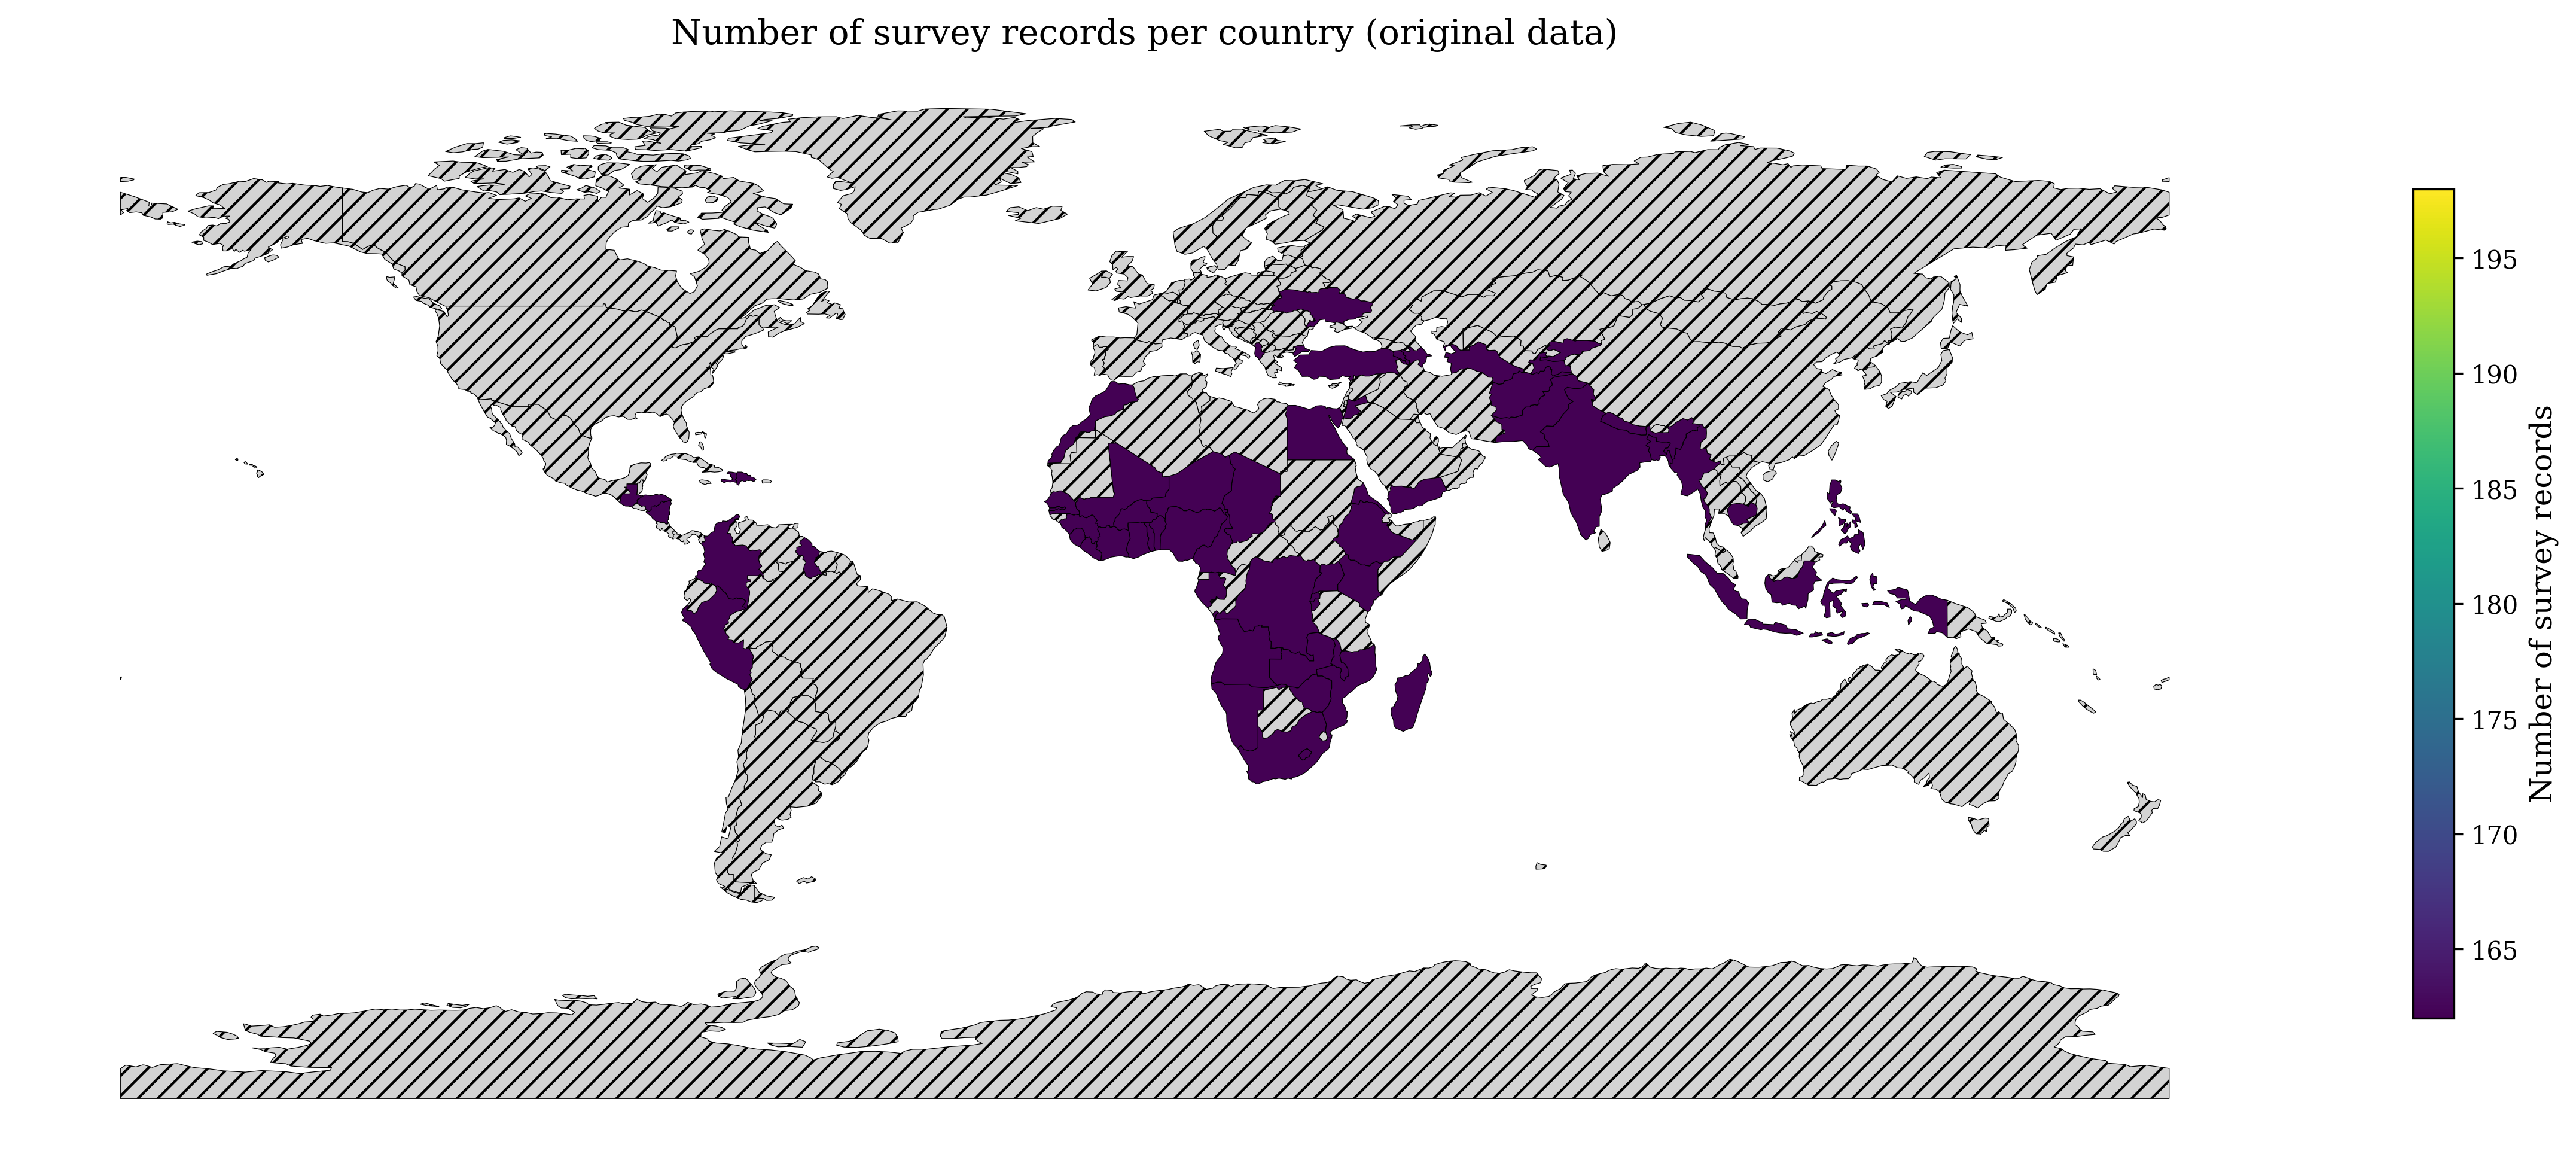

In [9]:
import os
import urllib.request
import pandas as pd
import geopandas as gpd
import pycountry
import matplotlib.pyplot as plt

# -----------------------------
# Helper: harmonize country names
# -----------------------------
def normalize_country(name: str) -> str:
    overrides = {
        "Congo Democratic Republic": "Democratic Republic of the Congo",
        "Congo Republic": "Republic of the Congo",
        "Cote d'Ivoire": "Ivory Coast",
        "Côte d’Ivoire": "Ivory Coast",
        "Viet Nam": "Vietnam",
        "Lao PDR": "Laos",
        "Sao Tome and Principe": "São Tomé and Príncipe",
        "Timor-Leste": "East Timor",
    }
    name = str(name).strip()
    if name in overrides:
        return overrides[name]
    try:
        return pycountry.countries.lookup(name).name
    except Exception:
        return name

# -----------------------------
# Read ORIGINAL dataset
# -----------------------------
df = pd.read_csv("Violence Against Women  Girls Data.csv")

country_counts = df["Country"].value_counts().reset_index()
country_counts.columns = ["Country", "N_records"]
country_counts["Country_std"] = country_counts["Country"].apply(normalize_country)

# -----------------------------
# Download Natural Earth Admin-0 countries (once)
# -----------------------------
NE_URL = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
ZIP_NAME = "ne_110m_admin_0_countries.zip"

if not os.path.exists(ZIP_NAME):
    print(f"Downloading Natural Earth countries to: {ZIP_NAME}")
    urllib.request.urlretrieve(NE_URL, ZIP_NAME)

# Read shapefile from inside the zip
# (the !... part points to the shapefile within the zip)
world = gpd.read_file(f"zip://{ZIP_NAME}!ne_110m_admin_0_countries.shp")

# Natural Earth typically stores the country name in "ADMIN"
if "ADMIN" not in world.columns:
    raise ValueError(f"Expected 'ADMIN' column not found. Available columns: {list(world.columns)}")

# Merge counts onto map
gdf = world.merge(country_counts, how="left", left_on="ADMIN", right_on="Country_std")

# -----------------------------
# Plot (paper-ready) + export
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

fig, ax = plt.subplots(figsize=(16, 8), dpi=300)

gdf.plot(
    column="N_records",
    ax=ax,
    cmap="viridis",
    linewidth=0.3,
    edgecolor="black",
    legend=True,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "black",
        "hatch": "///",
        "label": "No data"
    },
    legend_kwds={"label": "Number of survey records", "shrink": 0.6}
)

ax.set_title("Number of survey records per country (original data)")
ax.axis("off")
fig.tight_layout()

fig.savefig("number_of_records_per_country_map.png", dpi=600, bbox_inches="tight")
fig.savefig("number_of_records_per_country_map.pdf", bbox_inches="tight")

plt.show()
